## Rice growing counties in the Sacramento Valley, California

In [6]:
#importing libraries

import geopandas as gpd
import os
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [7]:
#define file paths

shape_files = "/group/moniergrp/dbaral/run_project/input_data/shape_files"
save_path = "/group/moniergrp/dbaral/run_project/output_data/map"

# Make output folder if it does not exist
os.makedirs(save_path, exist_ok=True)

In [8]:

# Load shapefile

counties = gpd.read_file(os.path.join(shape_files, "CA counties.shp"))

# Select rice-growing counties

rice_names = [
    "Butte", "Colusa", "Glenn", "Yolo", "Yuba",
    "Placer", "Sacramento", "San Joaquin", "Sutter"
]

rice_counties = counties[counties["NAME"].isin(rice_names)].copy()

In [9]:

# Ensure a projected CRS for better plotting/label placement
# EPSG:3310 = California Albers (good for California maps)

if counties.crs is None:
    raise ValueError("Shapefile CRS is missing. Please check the input shapefile.")

counties = counties.to_crs(epsg=3310)
rice_counties = rice_counties.to_crs(epsg=3310)


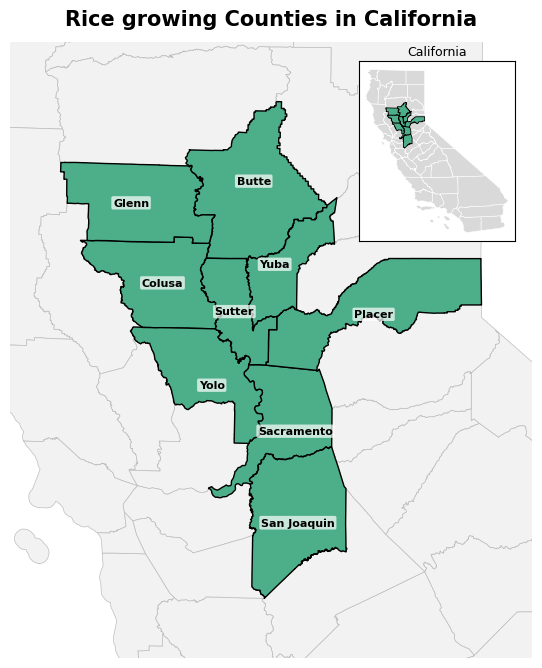

In [11]:

# Create figure

fig, ax = plt.subplots(figsize=(8, 8))


# Plot all California counties lightly in background

counties.plot(
    ax=ax,
    color="#f2f2f2",
    edgecolor="#bdbdbd",
    linewidth=0.5,
    zorder=1
)


# Highlight rice-growing counties

rice_counties.plot(
    ax=ax,
    color="#4daf8a",
    edgecolor="black",
    linewidth=1.0,
    zorder=2
)


# Add county labels
# representative_point() is safer than centroid for odd polygons

for _, row in rice_counties.iterrows():
    point = row.geometry.representative_point()
    ax.annotate(
        text=row["NAME"],
        xy=(point.x, point.y),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="black",
        zorder=3,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.7,
            boxstyle="round,pad=0.15"
        )
    )


# Zoom main map to rice-growing region with padding

xmin, ymin, xmax, ymax = rice_counties.total_bounds
xpad = (xmax - xmin) * 0.12
ypad = (ymax - ymin) * 0.12
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)


# Remove axes for clean publication look

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
for spine in ax.spines.values():
    spine.set_visible(False)


# Title

ax.set_title(
    "Rice growing Counties in California",
    fontsize=15,
    fontweight="bold",
    pad=12
)


# Inset map: full California with highlighted rice counties

ax_inset = inset_axes(
    ax,
    width="30%",
    height="30%",
    loc="upper right",
    borderpad=1.2
)

counties.plot(
    ax=ax_inset,
    color="#d9d9d9",
    edgecolor="white",
    linewidth=0.4
)

rice_counties.plot(
    ax=ax_inset,
    color="#4daf8a",
    edgecolor="black",
    linewidth=0.6
)

ax_inset.set_xticks([])
ax_inset.set_yticks([])
ax_inset.set_xlabel("")
ax_inset.set_ylabel("")

# show inset border
for spine in ax_inset.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_edgecolor("black")

ax_inset.set_title("California", fontsize=9, pad=4)


# Save figure

save_file = os.path.join(save_path, "rice_county_map.png")

plt.savefig(
    save_file,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()